# 01 — Data Loading & Validation
**Project:** Olist E-Commerce — Sales Funnel & RFM Analysis  
**Phase:** 1 of 5  
**Goal:** Load all 9 Olist tables, inspect structure, fix data types, validate relationships.

---

# Imports

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 9 tables

In [46]:
orders      = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
customers   = pd.read_csv("../data/raw/olist_customers_dataset.csv")
products    = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers     = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
payments    = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews     = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
category_t  = pd.read_csv("../data/raw/product_category_name_translation.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")

print("All tables loaded successfully")

All tables loaded successfully


# Check table sizes

In [47]:
"""
category_t table is just a translation table (Portuguese → English category names)
only used when you join products

geolocation table is massive (~1M rows) and only used for the map in the dashboard, 
not for funnel or RFM analysis

"""

tables = {
    "orders":      orders,
    "order_items": order_items,
    "customers":   customers,
    "payments":    payments,
    "reviews":     reviews,
    "products":    products,
    "sellers":     sellers,
}

for name, df in tables.items():
    print(f"{name:15s} → {df.shape[0]:>7,} rows  |  {df.shape[1]:>2} cols")

orders          →  99,441 rows  |   8 cols
order_items     → 112,650 rows  |   7 cols
customers       →  99,441 rows  |   5 cols
payments        → 103,886 rows  |   5 cols
reviews         →  99,224 rows  |   7 cols
products        →  32,951 rows  |   9 cols
sellers         →   3,095 rows  |   4 cols


# First look at the orders table

In [48]:
print("Shape:", orders.shape)
print("\nColumn names:")
print(orders.columns.tolist())
print("\nFirst 3 rows:")
orders.head(3)

Shape: (99441, 8)

Column names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


# Fix date columns

In [49]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Date columns converted:")
print(orders[date_cols].dtypes)

Date columns converted:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


# Check the date range

In [50]:
print("Earliest order:", orders["order_purchase_timestamp"].min())
print("Latest order:  ", orders["order_purchase_timestamp"].max())

Earliest order: 2016-09-04 21:15:19
Latest order:   2018-10-17 17:30:18


# Order status breakdown

In [51]:
status_counts = orders["order_status"].value_counts()
print(status_counts)
print(f"\nDelivered orders: {status_counts['delivered'] / len(orders) * 100:.1f}% of total")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Delivered orders: 97.0% of total


# Check missing values

In [52]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print("=== MISSING VALUES ACROSS ALL TABLES ===\n")

for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls_pct = (nulls / len(df) * 100).round(2)
    
    missing = pd.DataFrame({
        "missing": nulls, 
        "missing_%": nulls_pct
    })
    missing = missing[missing["missing"] > 0]
    
    if len(missing) > 0:
        print(f"--- {name} ---")
        print(missing)
        print()
    else:
        print(f"--- {name} --- ✓ no missing values\n")

=== MISSING VALUES ACROSS ALL TABLES ===

--- orders ---
                               missing  missing_%
order_approved_at                  160       0.16
order_delivered_carrier_date      1783       1.79
order_delivered_customer_date     2965       2.98

--- order_items --- ✓ no missing values

--- customers --- ✓ no missing values

--- payments --- ✓ no missing values

--- reviews ---
                        missing  missing_%
review_comment_title      87656      88.34
review_comment_message    58247      58.70

--- products ---
                            missing  missing_%
product_category_name           610       1.85
product_name_lenght             610       1.85
product_description_lenght      610       1.85
product_photos_qty              610       1.85
product_weight_g                  2       0.01
product_length_cm                 2       0.01
product_height_cm                 2       0.01
product_width_cm                  2       0.01

--- sellers --- ✓ no missing values



In [53]:
'''This categories were not included in the tables, as they are the translations and geolocation '''
print("category_t missing:", category_t.isnull().sum().sum())
print("geolocation missing:", geolocation.isnull().sum().sum())

category_t missing: 0
geolocation missing: 0


# Orders over time chart

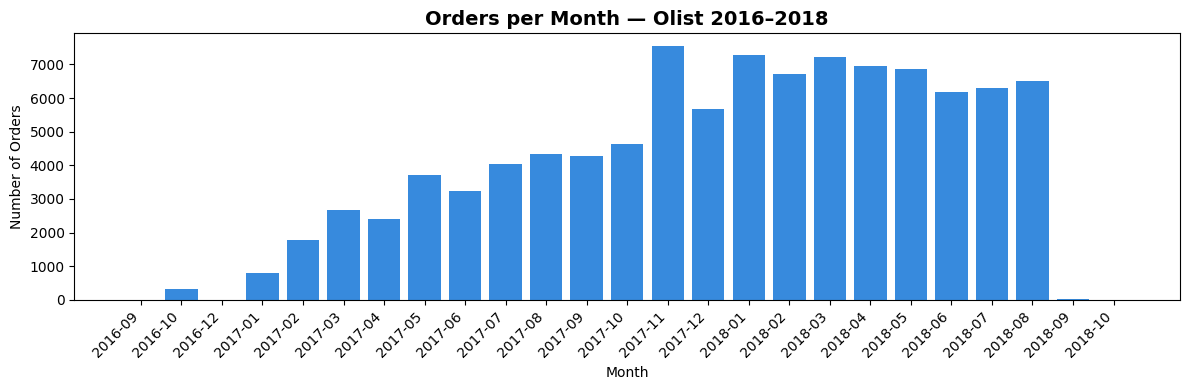

In [54]:
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")
monthly = orders.groupby("month").size().reset_index(name="order_count")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly["month"].astype(str), monthly["order_count"], color="#378ADD")
ax.set_title("Orders per Month — Olist 2016–2018", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/01_orders_over_time.png", dpi=150)
plt.show()

# Relationship check between tables

In [55]:
print("=== KEY RELATIONSHIP CHECKS ===\n")

# Every order_item should have a matching order
orphan_items = order_items[~order_items["order_id"].isin(orders["order_id"])]
print(f"order_items with no matching order:  {len(orphan_items)}")

# Every payment should have a matching order
orphan_payments = payments[~payments["order_id"].isin(orders["order_id"])]
print(f"payments with no matching order:     {len(orphan_payments)}")

# Every review should have a matching order
orphan_reviews = reviews[~reviews["order_id"].isin(orders["order_id"])]
print(f"reviews with no matching order:      {len(orphan_reviews)}")

print("\nAll zeros = clean joins. Any non-zero = data quality issue to investigate.")

=== KEY RELATIONSHIP CHECKS ===

order_items with no matching order:  0
payments with no matching order:     0
reviews with no matching order:      0

All zeros = clean joins. Any non-zero = data quality issue to investigate.


# Quick look at payments

In [56]:
print("Payment types:")
print(payments["payment_type"].value_counts())

print(f"\nAverage order value: R$ {payments.groupby('order_id')['payment_value'].sum().mean():.2f}")
print(f"Total revenue in dataset: R$ {payments['payment_value'].sum():,.2f}")

Payment types:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Average order value: R$ 160.99
Total revenue in dataset: R$ 16,008,872.12


# Quick look at reviews

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


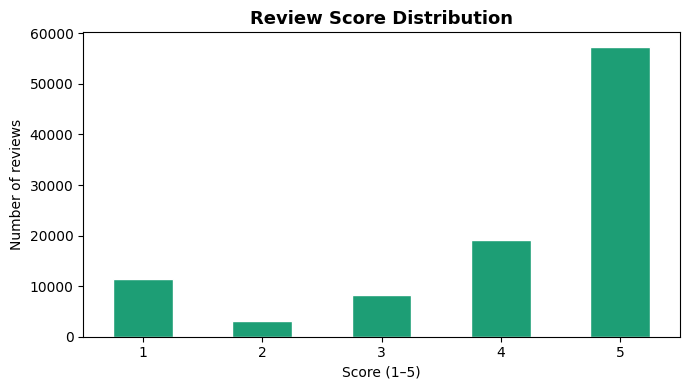

In [57]:
print("Review score distribution:")
print(reviews["review_score"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4))
reviews["review_score"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#1D9E75", edgecolor="white"
)
ax.set_title("Review Score Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Score (1–5)")
ax.set_ylabel("Number of reviews")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("../reports/01_review_distribution.png", dpi=150)
plt.show()

# Save a clean orders table

In [58]:
# Keep only delivered orders with no missing delivery dates
orders_clean = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
].copy()

orders_clean.to_csv("../data/processed/orders_clean.csv", index=False)

print(f"Original orders:  {len(orders):,}")
print(f"Clean orders:     {len(orders_clean):,}")
print(f"Removed:          {len(orders) - len(orders_clean):,}")
print("\nSaved to data/processed/orders_clean.csv")

Original orders:  99,441
Clean orders:     96,470
Removed:          2,971

Saved to data/processed/orders_clean.csv
